# Data Science em Vendas

**Problema de Negócio:**
Realizar previsão de vendas de uma rede de lojas.


**Dataset**: Dados históricos de vendas de 1.115 lojas da Rossmann. Disponível em: https://www.kaggle.com/c/rossmann-store-sales/data


Projeto estudado no treinamento "Ciência de Dados para Empresas e Negócios" de Jones Granatyr. Disponível em: https://www.udemy.com/course/ciencia-de-dados-para-empresas-e-negocios/

**Dicionário de Dados:**

Most of the fields are self-explanatory. The following are descriptions for those that aren't.

Id - an Id that represents a (Store, Date) duple within the test set

Store - a unique Id for each store

Sales - the turnover for any given day (this is what you are predicting)

Customers - the number of customers on a given day

Open - an indicator for whether the store was open: 0 = closed, 1 = open

StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None

SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools

StoreType - differentiates between 4 different store models: a, b, c, d

Assortment - describes an assortment level: a = basic, b = extra, c = extended

CompetitionDistance - distance in meters to the nearest competitor store

CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened

Promo - indicates whether a store is running a promo on that day

Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating

Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2

PromoInterval - describes the consecutive intervals 

Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

### Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

### Carregamento do dataset de vendas

In [ ]:
# Carga do csv
df_vendas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DS_para_negocios/3-Vendas/train.csv')

In [ ]:
# Visualização das primeiras linhas
df_vendas.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
# Número de registros e colunas

df_vendas.shape

(1017209, 9)

In [ ]:
# Variáveis e tipos

df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
# Estatísticas das variáveis numéricas

df_vendas.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


### Carregamento do dataset das lojas

In [ ]:
# Carga do csv
df_lojas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DS_para_negocios/3-Vendas/store.csv')

In [ ]:
# Visualização das primeiras linhas
df_lojas.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
# Número de registros e colunas

df_lojas.shape

(1115, 10)

In [ ]:
# Variáveis e tipos

df_lojas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [ ]:
# Estatísticas das variáveis numéricas

df_lojas.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


### Exploração dos dados

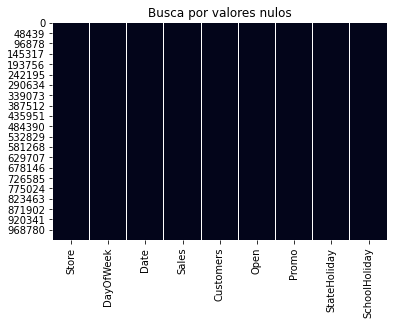

In [ ]:
# Busca por valores nulos nos dados das vendas (valores nulos são indicados em branco)

sns.heatmap(df_vendas.isnull(), cbar=False)
plt.title('Busca por valores nulos')
plt.show()

In [ ]:
# Contagem de valores nulos por variável

df_vendas.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

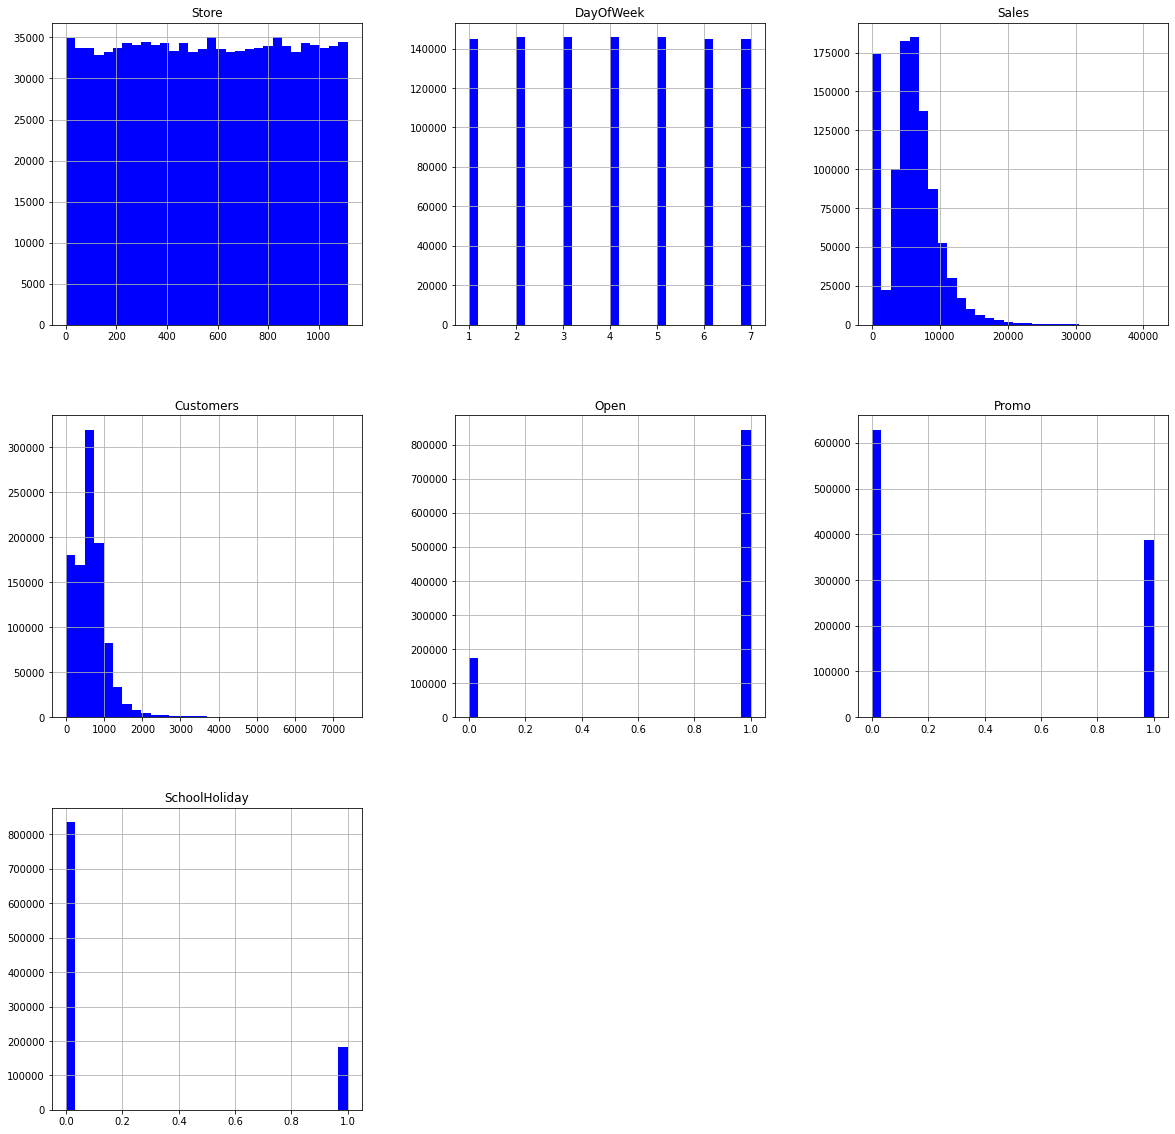

In [ ]:
# Histograma de cada variável

df_vendas.hist(bins=30, figsize=(20,20), color='blue')
plt.show()

In [ ]:
# Mantendo apenas os registros de lojas que estavam abertas

df_vendas = df_vendas[df_vendas['Open'] == 1]
df_vendas.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
# Exclusão da coluna Open

df_vendas.drop('Open', axis=1, inplace=True)
df_vendas.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1


In [ ]:
# Estatísticas das variáveis numéricas

df_vendas.describe()

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000


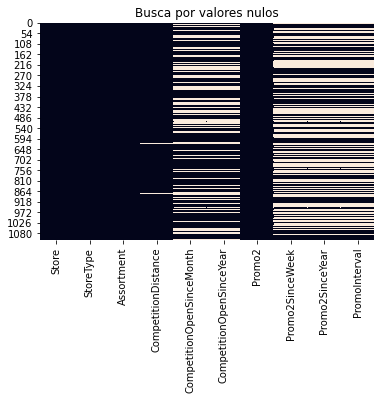

In [ ]:
# Busca por valores nulos nos dados das lojas (valores nulos são indicados em branco)

sns.heatmap(df_lojas.isnull(), cbar=False)
plt.title('Busca por valores nulos')
plt.show()

In [ ]:
# Contagem de valores nulos por variável

df_lojas.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [ ]:
# Tratamento dos valores missing (preenchimento com valor 0)

colunas = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']
for coluna in colunas:
  df_lojas[coluna].fillna(0, inplace=True)

In [ ]:
# Tratamento dos valores missing (preenchimento com a média da coluna)

df_lojas['CompetitionDistance'].fillna(df_lojas['CompetitionDistance'].mean(), inplace=True)

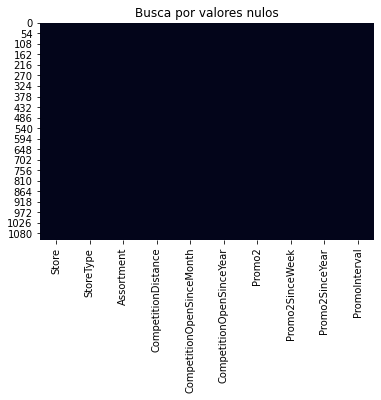

In [ ]:
# Busca por valores nulos nos dados das lojas (valores nulos são indicados em branco)

sns.heatmap(df_lojas.isnull(), cbar=False)
plt.title('Busca por valores nulos')
plt.show()

In [ ]:
# Contagem de valores nulos por variável

df_lojas.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

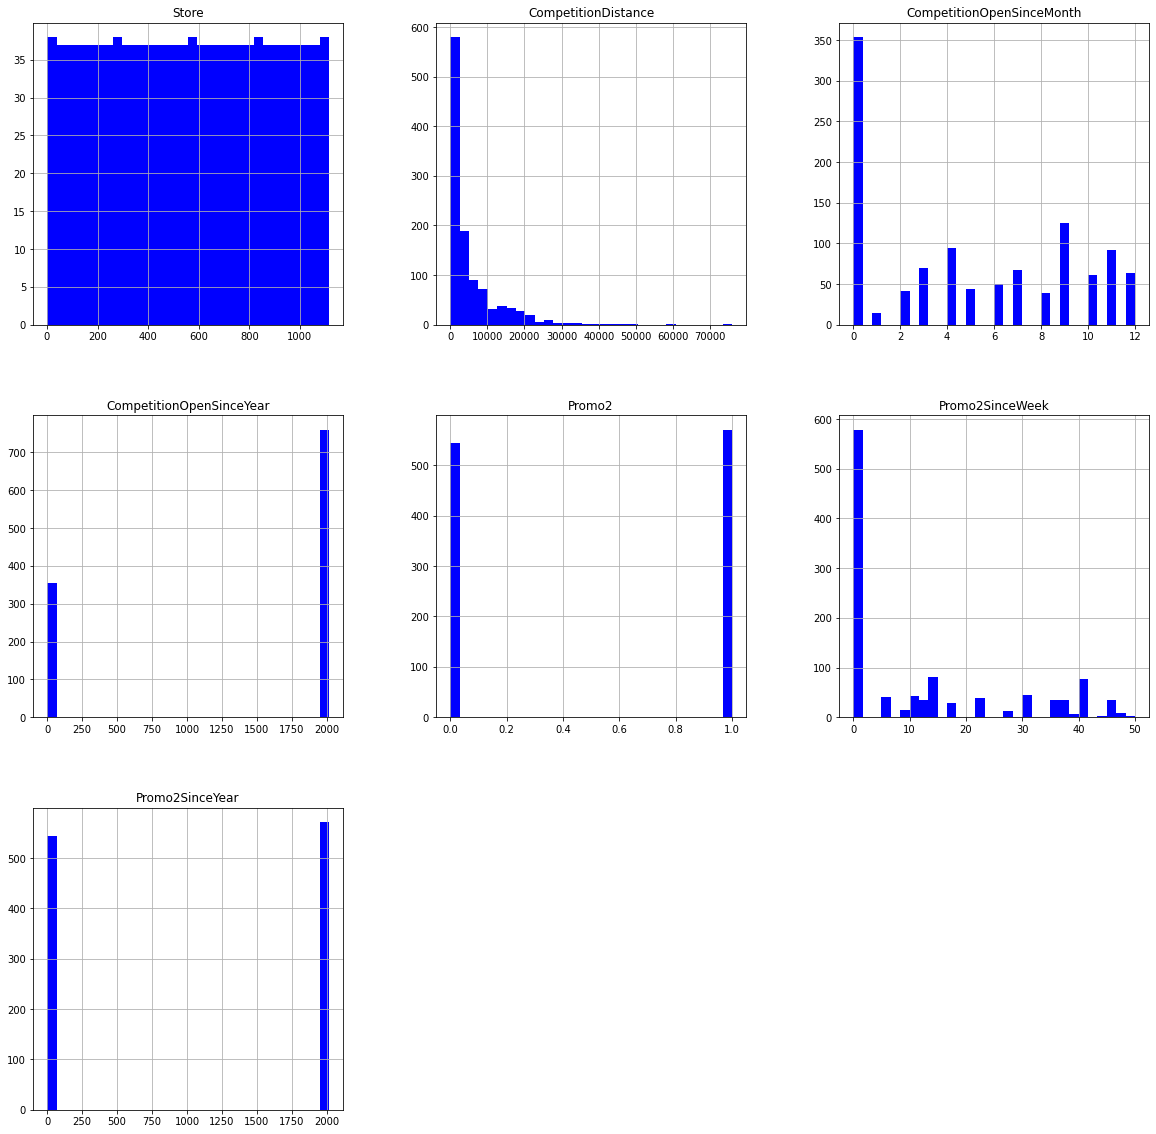

In [ ]:
# Histograma de cada variável

df_lojas.hist(bins=30, figsize=(20,20), color='blue')
plt.show()

### Junção dos Dataframes

In [ ]:
# Unindo os dataframes

dataset = pd.merge(df_vendas, df_lojas, how='inner', on='Store')
dataset.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,1,4,2015-07-30,5020,546,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
2,1,3,2015-07-29,4782,523,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
3,1,2,2015-07-28,5011,560,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
4,1,1,2015-07-27,6102,612,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0


In [ ]:
# Número de registros e colunas

dataset.shape

(844392, 17)

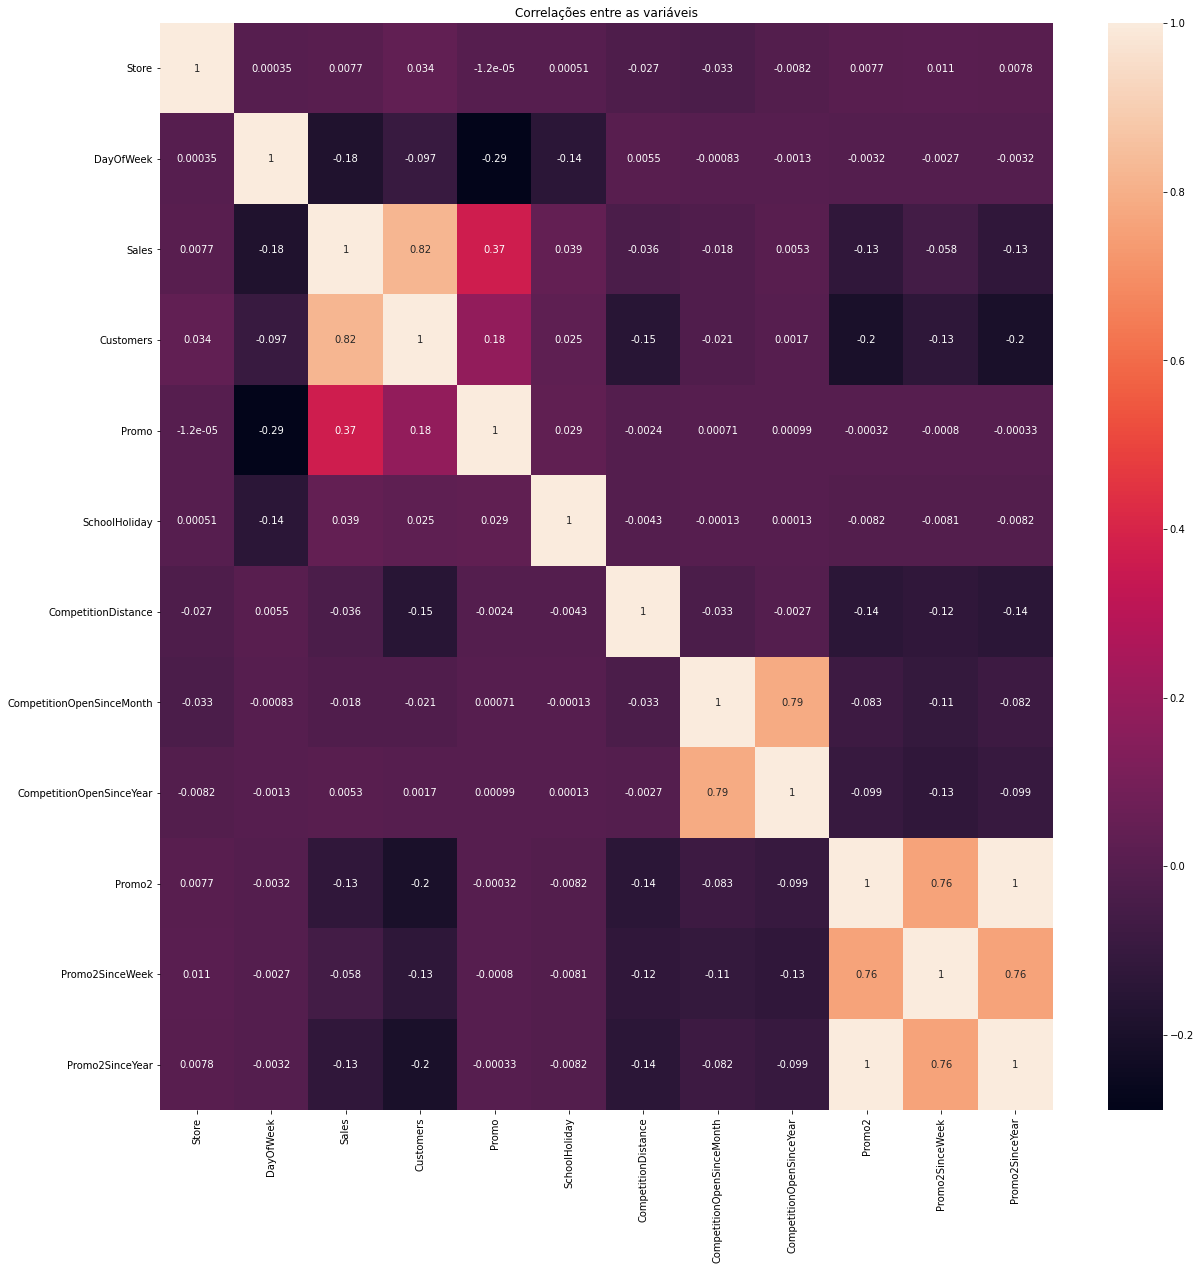

In [ ]:
# Correlações entre as variáveis

correlacoes = dataset.corr()
f, ax = plt.subplots(figsize=(20,20))
sns.heatmap(correlacoes, annot=True )
plt.title('Correlações entre as variáveis')
plt.show()

In [ ]:
# Ranking de Correlações com a variável Sales

correlacoes = dataset.corr()['Sales'].sort_values()
correlacoes

DayOfWeek                   -0.178736
Promo2SinceYear             -0.127621
Promo2                      -0.127596
Promo2SinceWeek             -0.058476
CompetitionDistance         -0.036343
CompetitionOpenSinceMonth   -0.018370
CompetitionOpenSinceYear     0.005266
Store                        0.007710
SchoolHoliday                0.038617
Promo                        0.368145
Customers                    0.823597
Sales                        1.000000
Name: Sales, dtype: float64

In [ ]:
# Quebra de granularidade na data

dataset['Year'] = pd.DatetimeIndex(dataset['Date']).year
dataset['Month'] = pd.DatetimeIndex(dataset['Date']).month
dataset['Day'] = pd.DatetimeIndex(dataset['Date']).day
dataset.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,1,4,2015-07-30,5020,546,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,30
2,1,3,2015-07-29,4782,523,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,29
3,1,2,2015-07-28,5011,560,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,28
4,1,1,2015-07-27,6102,612,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,27


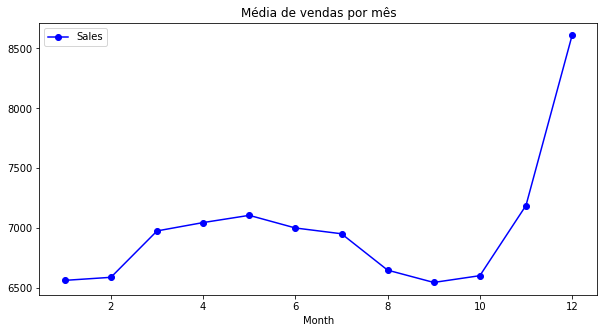

In [ ]:
# Visualização de média de vendas por mês

eixo = dataset.groupby(by='Month')[['Sales']].mean().plot(figsize=(10,5), marker='o', color='b')
eixo.set_title('Média de vendas por mês')
plt.show()

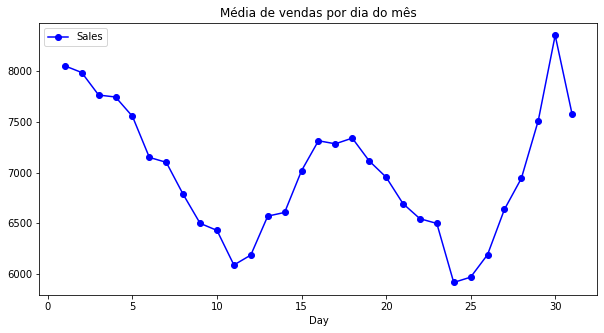

In [ ]:
# Visualização de média de vendas por dia do mês

eixo = dataset.groupby(by='Day')[['Sales']].mean().plot(figsize=(10,5), marker='o', color='b')
eixo.set_title('Média de vendas por dia do mês')
plt.show()

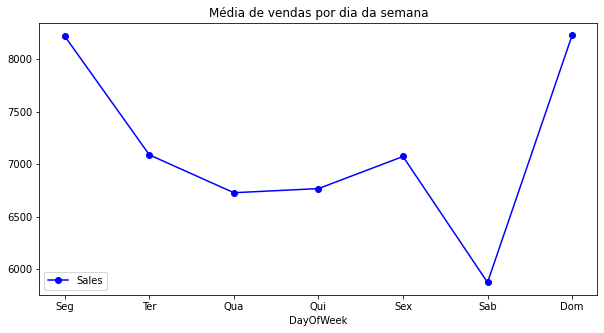

In [ ]:
# Visualização de média de vendas por dia da semana

eixo = dataset.groupby(by='DayOfWeek')[['Sales']].mean().plot(figsize=(10,5), marker='o', color='b')
eixo.set_title('Média de vendas por dia da semana')
eixo.set_xticklabels([' ','Seg','Ter','Qua','Qui','Sex','Sab','Dom'])
plt.show()

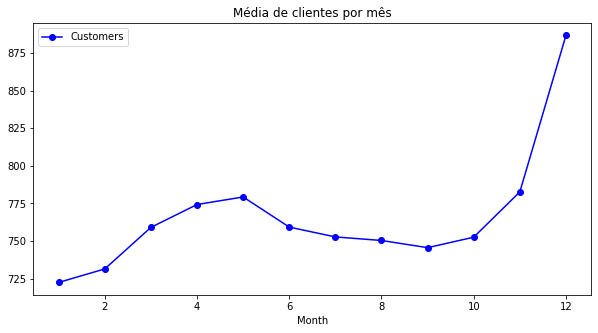

In [ ]:
# Visualização de média de clientes por mês

eixo = dataset.groupby(by='Month')[['Customers']].mean().plot(figsize=(10,5), marker='o', color='b')
eixo.set_title('Média de clientes por mês')
plt.show()

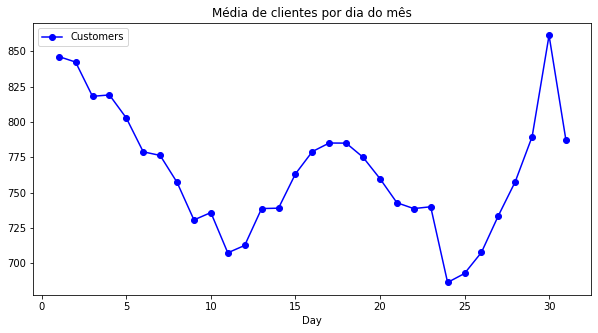

In [ ]:
# Visualização de média de clientes por dia do mês

eixo = dataset.groupby(by='Day')[['Customers']].mean().plot(figsize=(10,5), marker='o', color='b')
eixo.set_title('Média de clientes por dia do mês')
plt.show()

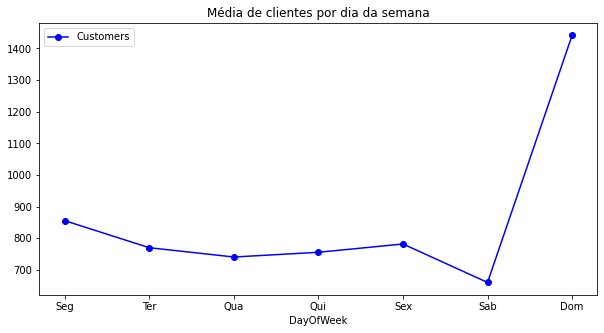

In [ ]:
# Visualização de média de clientes por dia da semana

eixo = dataset.groupby(by='DayOfWeek')[['Customers']].mean().plot(figsize=(10,5), marker='o', color='b')
eixo.set_title('Média de clientes por dia da semana')
eixo.set_xticklabels([' ','Seg','Ter','Qua','Qui','Sex','Sab','Dom'])
plt.show()

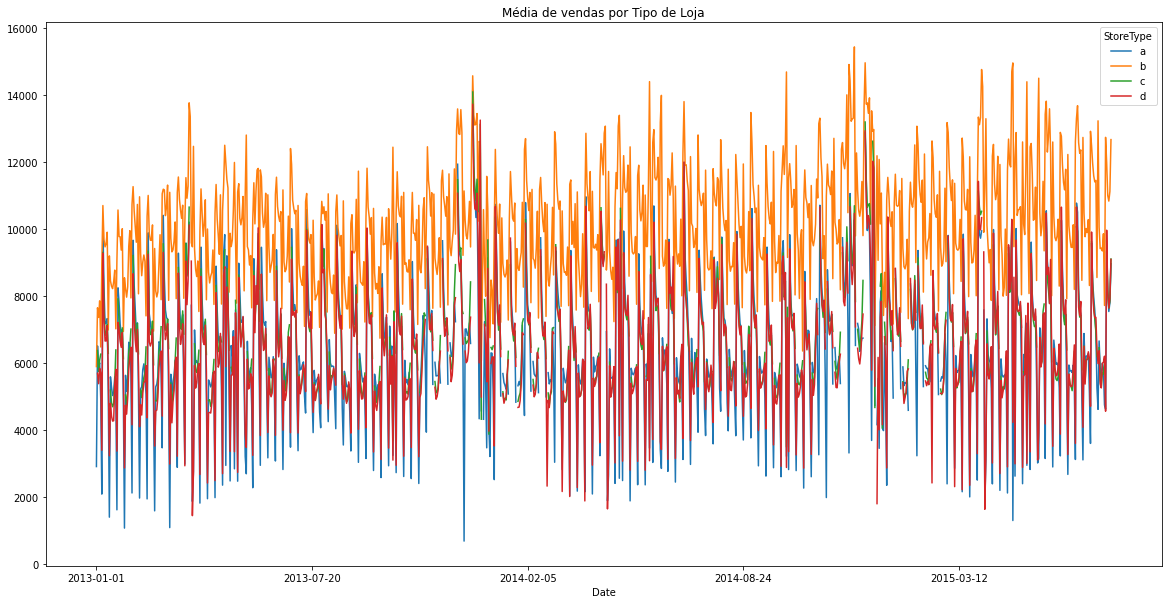

In [ ]:
# Visualização da média de vendas por Tipo de Loja
fig, ax = plt.subplots(figsize = (20,10))
dataset.groupby(['Date','StoreType']).mean()['Sales'].unstack().plot(ax = ax)
ax.set_title('Média de vendas por Tipo de Loja')
plt.show()

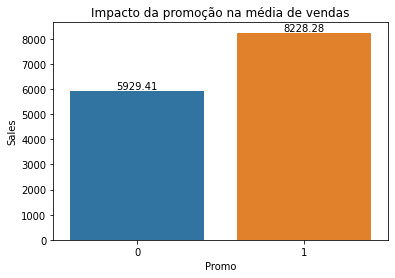

In [ ]:
# Visualização do impacto da promoção na média de vendas

ax = sns.barplot(x = 'Promo', y='Sales', data=dataset)
ax.set_title('Impacto da promoção na média de vendas')

rects = ax.patches
labels = [dataset[dataset.Promo == 0]['Sales'].mean(), dataset[dataset.Promo == 1]['Sales'].mean()]
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height, '{:.2f}'.format(label), ha='center', va='bottom')    

plt.show()

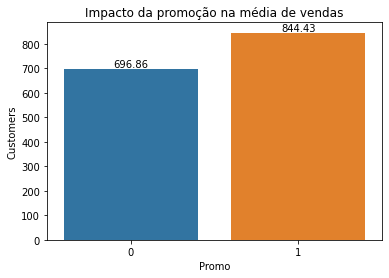

In [ ]:
# Visualização do impacto da promoção na média de clientes na loja

ax = sns.barplot(x = 'Promo', y='Customers', data=dataset)
ax.set_title('Impacto da promoção na média de vendas')

rects = ax.patches
labels = [dataset[dataset.Promo == 0]['Customers'].mean(), dataset[dataset.Promo == 1]['Customers'].mean()]
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height, '{:.2f}'.format(label), ha='center', va='bottom')    

plt.show()

### Construção do Modelo

In [ ]:
# Importação do pacote Prophet

from fbprophet import Prophet

In [ ]:
# Criação da função de previsão e modificação dos nomes das variáveis de acordo com o esperado pelo pacote Prophet

def previsao_vendas(id_loja, df_vendas, periodos):
  df_vendas_loja = df_vendas[df_vendas['Store'] == id_loja]
  df_vendas_loja = df_vendas_loja[['Date','Sales']].rename(columns = {'Date': 'ds', 'Sales': 'y'})
  df_vendas_loja = df_vendas_loja.sort_values(by='ds')

  modelo = Prophet()
  modelo.fit(df_vendas_loja)
  valores_futuros = modelo.make_future_dataframe(periods=periodos)
  previsoes = modelo.predict(valores_futuros)

  grafico1 = modelo.plot(previsoes, xlabel = 'Datas', ylabel = 'Valor de Vendas')
  grafico2 = modelo.plot_components(previsoes)

  return df_vendas_loja, previsoes

INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


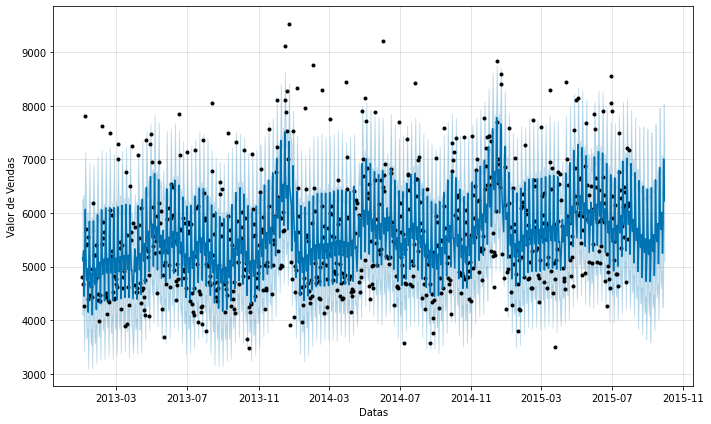

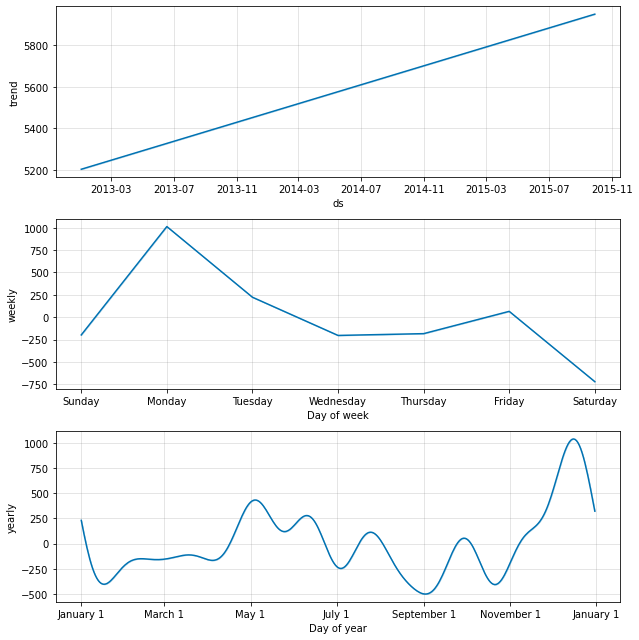

In [ ]:
# Teste da função criada

df_original, df_previsoes = previsao_vendas(10, dataset, 60)

In [ ]:
# Visualização das previsões

df_previsoes.tail(60)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
784,2015-08-01,5904.754320,4217.353712,6282.260683,5904.754320,5904.754320,-673.734983,-673.734983,-673.734983,-719.174286,-719.174286,-719.174286,45.439303,45.439303,45.439303,0.0,0.0,0.0,5231.019337
785,2015-08-02,5905.498641,4670.287959,6701.453970,5905.498641,5905.498641,-172.385687,-172.385687,-172.385687,-197.423916,-197.423916,-197.423916,25.038229,25.038229,25.038229,0.0,0.0,0.0,5733.112954
786,2015-08-03,5906.242962,5902.841458,7915.447403,5906.242962,5906.242962,1015.917486,1015.917486,1015.917486,1013.040634,1013.040634,1013.040634,2.876853,2.876853,2.876853,0.0,0.0,0.0,6922.160448
787,2015-08-04,5906.987283,5108.799155,7190.425960,5906.987283,5906.987283,202.989916,202.989916,202.989916,223.673781,223.673781,223.673781,-20.683865,-20.683865,-20.683865,0.0,0.0,0.0,6109.977199
788,2015-08-05,5907.731604,4522.551927,6707.476543,5907.731604,5907.731604,-248.332224,-248.332224,-248.332224,-203.046067,-203.046067,-203.046067,-45.286157,-45.286157,-45.286157,0.0,0.0,0.0,5659.399381
789,2015-08-06,5908.475925,4623.362765,6756.737602,5908.475925,5908.475925,-253.597221,-253.597221,-253.597221,-183.012971,-183.012971,-183.012971,-70.584250,-70.584250,-70.584250,0.0,0.0,0.0,5654.878705
790,2015-08-07,5909.220246,4844.110538,7007.734689,5909.220246,5909.220246,-30.309420,-30.309420,-30.309420,65.942825,65.942825,65.942825,-96.252245,-96.252245,-96.252245,0.0,0.0,0.0,5878.910826
791,2015-08-08,5909.964567,4075.624427,6199.662958,5909.964567,5909.964567,-841.165148,-841.165148,-841.165148,-719.174286,-719.174286,-719.174286,-121.990862,-121.990862,-121.990862,0.0,0.0,0.0,5068.799419
792,2015-08-09,5910.708888,4560.467726,6720.270640,5910.708887,5910.708890,-344.956807,-344.956807,-344.956807,-197.423916,-197.423916,-197.423916,-147.532891,-147.532891,-147.532891,0.0,0.0,0.0,5565.752082
793,2015-08-10,5911.453209,5716.706353,7791.247993,5911.453202,5911.453221,840.393413,840.393413,840.393413,1013.040634,1013.040634,1013.040634,-172.647221,-172.647221,-172.647221,0.0,0.0,0.0,6751.846622


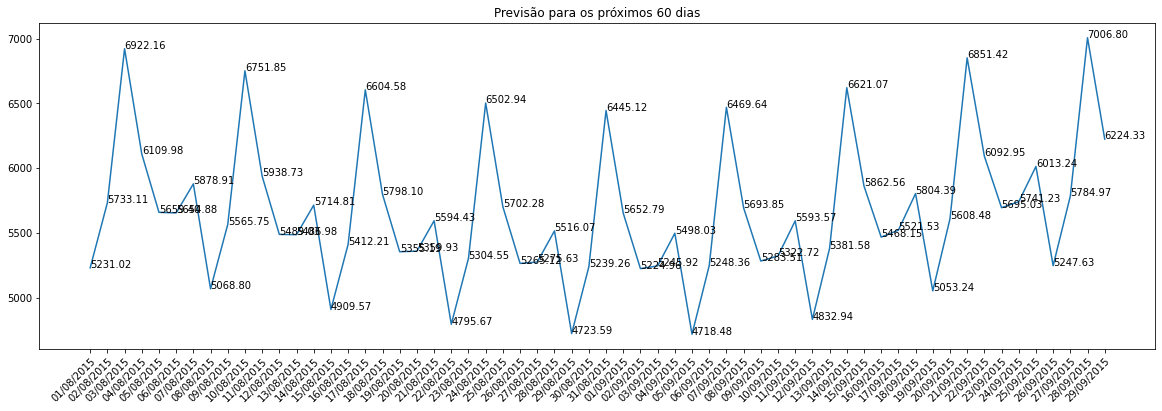

In [ ]:
# Visualização das previsões

fig = plt.figure(figsize=(20,6))
ax = df_previsoes.yhat.tail(60).plot()

ax.set_title('Previsão para os próximos 60 dias')
ax.set_xticks(df_previsoes.index[-60:])
ax.set_xticklabels([x.strftime('%d/%m/%Y') for x in df_previsoes.ds.tail(60)], rotation=45, ha='right', rotation_mode='anchor')

for i,j in df_previsoes.yhat.tail(60).items():
    ax.annotate('{:.2f}'.format(j), xy=(i, j))

plt.show()

In [ ]:
# Exportando as previsões

df_previsoes.yhat.tail(60).to_csv('previsoes.csv')

# **O trabalho de previsão está concluído e o arquivo csv pode ser enviado para a equipe de Vendas.**

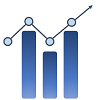 Outros projetos em https://thiagocmelods.github.io/